Dataset shape: (125, 90)
Dataset Entropy: 2.321928094887362
Dataset Gini: 0.7999999999999999
Root Feature Index: 75


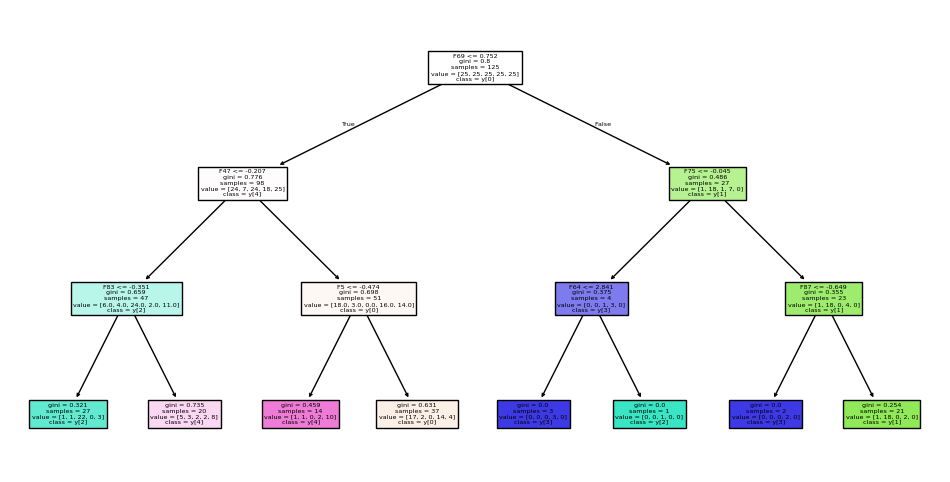

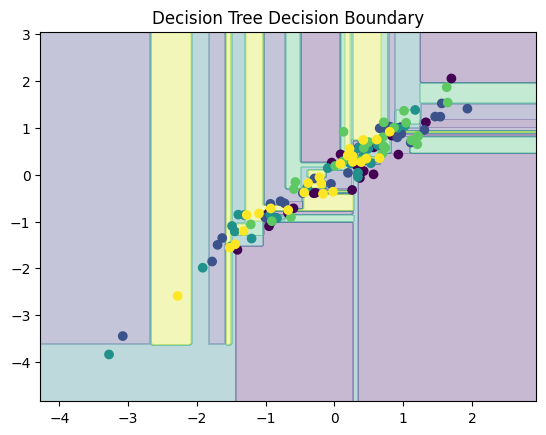

In [ ]:
# LAB 06 – DECISION TREE MODULE

import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# A1 – ENTROPY

def calculate_entropy(y):

    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()

    entropy = -np.sum(probabilities * np.log2(probabilities))

    return entropy


# EQUAL WIDTH BINNING

def equal_width_binning(data, bins=4):

    min_val = np.min(data)
    max_val = np.max(data)

    width = (max_val - min_val) / bins

    binned = np.floor((data - min_val) / width)

    binned[binned == bins] = bins - 1

    return binned.astype(int)


# A2 – GINI INDEX

def calculate_gini(y):

    values, counts = np.unique(y, return_counts=True)

    probabilities = counts / counts.sum()

    gini = 1 - np.sum(probabilities ** 2)

    return gini


# INFORMATION GAIN

def information_gain(X_column, y):

    parent_entropy = calculate_entropy(y)

    values = np.unique(X_column)

    weighted_entropy = 0

    for value in values:

        subset_y = y[X_column == value]

        weight = len(subset_y) / len(y)

        weighted_entropy += weight * calculate_entropy(subset_y)

    gain = parent_entropy - weighted_entropy

    return gain


# A3 – ROOT NODE DETECTION

def find_root_node(X, y):

    n_features = X.shape[1]

    gains = []

    for i in range(n_features):

        gain = information_gain(X[:, i], y)

        gains.append(gain)

    root_feature = np.argmax(gains)

    return root_feature, gains


# A4 – BINNING CONTINUOUS FEATURES

def bin_dataset(X, bins=4):

    X_binned = np.zeros_like(X)

    for i in range(X.shape[1]):

        X_binned[:, i] = equal_width_binning(X[:, i], bins)

    return X_binned


# SIMPLE DECISION TREE NODE

class Node:

    def __init__(self, feature=None, value=None, left=None, right=None, label=None):

        self.feature = feature
        self.value = value
        self.left = left
        self.right = right
        self.label = label


# BUILD DECISION TREE

def build_tree(X, y, depth=0, max_depth=3):

    if len(np.unique(y)) == 1:
        return Node(label=y[0])

    if depth >= max_depth:
        values, counts = np.unique(y, return_counts=True)
        return Node(label=values[np.argmax(counts)])

    feature, gains = find_root_node(X, y)

    values = np.unique(X[:, feature])

    value = values[0]

    left_mask = X[:, feature] == value
    right_mask = X[:, feature] != value

    left = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth)
    right = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth)

    return Node(feature, value, left, right)


# PREDICTION USING CUSTOM TREE

def predict_tree(node, x):

    if node.label is not None:
        return node.label

    if x[node.feature] == node.value:
        return predict_tree(node.left, x)
    else:
        return predict_tree(node.right, x)


# A6 – SKLEARN TREE VISUALIZATION

def visualize_tree(X, y, feature_names):

    model = DecisionTreeClassifier(max_depth=3)

    model.fit(X, y)

    plt.figure(figsize=(12,6))

    plot_tree(model,
              feature_names=feature_names,
              class_names=True,
              filled=True)

    plt.show()

    return model


# A7 – DECISION BOUNDARY (2 FEATURES)

def plot_decision_boundary(X, y):

    model = DecisionTreeClassifier()

    model.fit(X, y)

    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(X[:,0], X[:,1], c=y)

    plt.title("Decision Tree Decision Boundary")

    plt.show()


# MAIN

if __name__ == "__main__":

    # LOAD DATASET
    X = np.load("X_features.npy")
    y = np.load("y_labels.npy")

    print("Dataset shape:", X.shape)

    # SCALE FEATURES
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # A1 ENTROPY
    entropy_value = calculate_entropy(y)
    print("Dataset Entropy:", entropy_value)

    # A2 GINI
    gini_value = calculate_gini(y)
    print("Dataset Gini:", gini_value)

    # A3 ROOT NODE
    X_binned = bin_dataset(X_scaled)
    root_feature, gains = find_root_node(X_binned, y)
    print("Root Feature Index:", root_feature)

    # A5 BUILD CUSTOM TREE
    tree = build_tree(X_binned, y)

    # A6 VISUALIZE TREE
    feature_names = [f"F{i}" for i in range(X.shape[1])]
    visualize_tree(X_scaled, y, feature_names)

    # A7 DECISION BOUNDARY
    X_two_features = X_scaled[:, :2]
    plot_decision_boundary(X_two_features, y)